#Mohd Nizam Mohd Nasir Shaikh
##Student ID: 24198170
##Course: MSc in FinTech (MSCTFTD1)
##Module: AI for Finance
##Professor: Furqan Rustam


# CA2 60% AI for Finance: Cryptocurrency Portfolio Prediction and Lightweight Time-Series Modelling

#Aim
The objective is to predict next period returns and build a portfolio selection prototype that is Adaptive for cryptocurrency portfolio management.

This notebook implements a multi model AI pipeline using the **Top 100 Cryptocurrency (2020–2025)** from Kaggle dataset.

Link: https://www.kaggle.com/datasets/imtkaggleteam/top-100-cryptocurrency-2020-2025

## Objectives
- Load and clean the full dataset across all available symbols
- Engineer **ratio normalised** financial features that are scale invariant across assets
- Apply log return transformation and winsorisation to the prediction target
- Build and compare five models: Random Forest, XGBoost, CNN, LSTM & GRU
- Evaluate portfolio performance with transaction cost adjustment
- Explain model predictions using SHAP

## Key Design Decisions (and why they differ from a naive baseline)
- **All 100 symbols** are used this provides ~240k training rows which is critical for deep learning
- **Raw OHLC prices are removed** — BTC averages 35,000 USD while DOGE averages 0.11 USD, a 321,000× scale difference that StandardScaler cannot neutralise when features are mixed across assets
- **Log return target with winsorisation** — raw percentage returns have a skewness of 17.6 and extreme outliers that dominate MSE; log returns are more normally distributed and winsorising at ±3σ removes 181 **noise driven** extreme events without losing real signal
- **Ratio-normalised features** (price/MA, price position within Bollinger Bands) are scale invariant and comparable across all assets regardless of absolute price level
- **Lookback = 20** for sequence models instead of 10, giving recurrent layers more temporal context

## Installing and importing libraries

In [1]:
!pip -q install ta xgboost shap tensorflow

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as wf_mae

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Input,
    Conv1D, MaxPooling1D,
    LSTM, GRU, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

import shap

print("TF version:", tf.__version__)
print("All libraries loaded successfully")

TF version: 2.19.0
All libraries loaded successfully


## Load dataset

The dataset is loaded from local Colab storage.  
Expected columns include:

- symbol
- date
- open
- high
- low
- close
- network

In [4]:
df_raw = pd.read_excel("top_100_cryptocurrency_2020_2025 - 24198170.xlsm", sheet_name="top_100_cryptocurrency_20_25", engine="openpyxl")

In [5]:
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (211679, 7)


,symbol,date,open,high,low,close,network
0,BTCUSDT,2018-08-01,7735.67,7750.00,7430.00,7604.58,Bitcoin
1,BTCUSDT,2018-08-02,7600.08,7709.46,7455.72,7525.71,Bitcoin
2,BTCUSDT,2018-08-03,7525.71,7540.00,7282.44,7418.78,Bitcoin
3,BTCUSDT,2018-08-04,7412.27,7494.81,6926.00,7009.84,Bitcoin
4,BTCUSDT,2018-08-05,7009.84,7089.87,6882.29,7024.19,Bitcoin


## Inspect structure and missing values

We first inspect:
- dataset dimensions,
- column names,
- data types,
- missing values,
- duplicate rows.

In [ ]:
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nDtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nSymbol count:", df_raw['symbol'].nunique() if 'symbol' in df_raw.columns else df_raw.iloc[:,0].nunique())

Shape: (211679, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'network']

Dtypes:
 symbol      object
date        object
open       float64
high       float64
low        float64
close      float64
network     object
dtype: object

Missing values:
 symbol     0
date       0
open       0
high       0
low        0
close      0
network    0
dtype: int64

Duplicate rows: 0

Symbol count: 100


## Clean and sort the data

Cleaning includes:
- Standardising column names
- Converting date to datetime (day first format)
- Converting OHLC to numeric
- Removing duplicates and rows with missing essential values
- Sorting chronologically per asset

In [ ]:
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

required_cols = ['symbol', 'date', 'open', 'high', 'low', 'close']
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

for col in ['open', 'high', 'low', 'close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates()
df = df.dropna(subset=required_cols).copy()
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Symbols:", df['symbol'].nunique())
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
display(df.head())

Cleaned shape: (211679, 7)
Symbols: 100
Date range: 2018-08-01 to 2025-08-05


,symbol,date,open,high,low,close,network
0,ADAUSDT,2018-08-01,0.14152,0.14474,0.13500,0.13984,Cardano
1,ADAUSDT,2018-08-02,0.13983,0.14149,0.12850,0.13039,Cardano
2,ADAUSDT,2018-08-03,0.13079,0.13473,0.12290,0.12947,Cardano
3,ADAUSDT,2018-08-04,0.12941,0.13358,0.12353,0.12639,Cardano
4,ADAUSDT,2018-08-05,0.12622,0.13130,0.12440,0.13024,Cardano


## Use all available symbols

**Design decision:** The original approach filtered to only 7 coins, leaving 13,000 training rows.
 Using all 100 symbols providing approximately 200,000 rows — a 15x increase in training data that is critical for deep learning models to learn meaningful patterns.

Symbols with fewer than 200 trading days are excluded to ensure reliable rolling window feature
computation 50 day and 200 day moving averages require minimum history.

In [ ]:
# Keep symbols that have at least 200 daily observations
symbol_counts = df.groupby('symbol')['date'].count()
valid_symbols  = symbol_counts[symbol_counts >= 200].index.tolist()
df = df[df['symbol'].isin(valid_symbols)].copy()
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print(f"Valid symbols (>=200 days): {len(valid_symbols)}")
print(f"Total rows after filter:    {len(df):,}")
print("\nRows per symbol (top 10):")
print(df['symbol'].value_counts().head(10))

Valid symbols (>=200 days): 100
Total rows after filter:    211,679

Rows per symbol (top 10):
symbol
ADAUSDT    2562
ETHUSDT    2562
BNBUSDT    2562
BTCUSDT    2562
ETCUSDT    2562
XRPUSDT    2562
VETUSDT    2562
ONTUSDT    2562
LTCUSDT    2562
NEOUSDT    2562
Name: count, dtype: int64


## Plot normalised price trends

Prices are plotted normalised price / first observation so that all assets are visible on the same axis regardless of their absolute price levels.

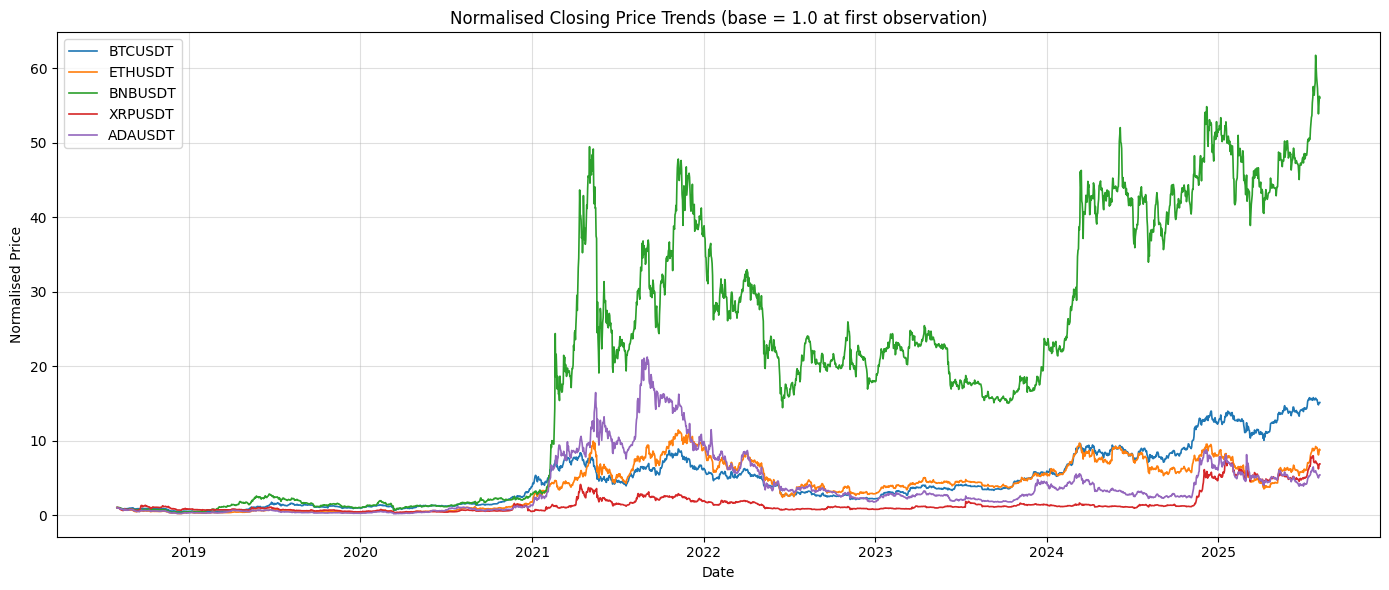

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'ADAUSDT']
for sym in plot_symbols:
    temp = df[df['symbol'] == sym].copy()
    if len(temp) < 10:
        continue
    norm_price = temp['close'] / temp['close'].iloc[0]
    ax.plot(temp['date'], norm_price, label=sym, linewidth=1.2)

ax.set_title('Normalised Closing Price Trends (base = 1.0 at first observation)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Price')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Feature engineering — ratio normalised, scale invariant features

**Critical improvement over the baseline:**
`open`, `high`, `low`, `close` values as features.
This is problematic because Bitcoin trades at ~35,000 USD while Dogecoin trades at ~0.11 USD — a 321,000× difference in magnitude. When these are mixed together in a single feature column and then standardised, the StandardScaler produces meaningless values because the distribution reflects price level differences between assets not predictive patterns.

**Replacing all raw price features with ratio based equivalents:**
- `price / MA(n)` — how far price is from its n-day moving average (comparable across all assets)
- `MA(5) / MA(20)` — golden/death cross signal (scale-invariant)
- Bollinger Band `%B` position — where price sits within its own volatility envelope
- Normalised MACD differential divided by price

All return features use **log returns** (ln(P_t / P_{t-1})) which are more normally distributed
than raw percentage changes and additive over time.

**Target variable:**
Log return of next close is winsorised at ±3 standard deviations to remove extreme outlier events that would otherwise dominate the MSE loss function and destabilise model training.

In [ ]:
def add_features_v3(g):
    g = g.sort_values('date').copy()
    c = g['close'].astype(float)
    o = g['open'].astype(float)
    h = g['high'].astype(float)
    l = g['low'].astype(float)

    g['log_ret_1'] = np.log(c / c.shift(1))
    g['log_ret_3'] = np.log(c / c.shift(3))
    g['log_ret_5'] = np.log(c / c.shift(5))
    g['log_ret_10'] = np.log(c / c.shift(10))

    for w in [5, 10, 20, 50]:
        g[f'ma_{w}'] = c.rolling(w, min_periods=w).mean()
        g[f'ma_dist_{w}'] = (c / (g[f'ma_{w}'] + 1e-8) - 1).clip(-1, 1)

    g['ma_5_20'] = (g['ma_5'] / (g['ma_20'] + 1e-8) - 1).clip(-1, 1)
    g['ma_10_50'] = (g['ma_10'] / (g['ma_50'] + 1e-8) - 1).clip(-1, 1)

    g['vol_10'] = g['log_ret_1'].rolling(10, min_periods=10).std()
    g['vol_20'] = g['log_ret_1'].rolling(20, min_periods=20).std()
    g['vol_regime'] = (g['vol_10'] / (g['vol_20'] + 1e-8)).clip(0, 5)

    g['trend_10'] = (c / c.shift(10) - 1).clip(-1, 1)
    g['trend_20'] = (c / c.shift(20) - 1).clip(-1, 1)

    g['hl_spread'] = ((h - l) / (c + 1e-8)).clip(0, 2)
    g['candle_body'] = ((c - o) / ((h - l) + 1e-8)).clip(-1, 1)

    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    loss = (-delta.clip(upper=0)).rolling(14, min_periods=14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    g['rsi_norm'] = ((rsi - 50) / 50).clip(-1, 1)

    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    sig = macd.ewm(span=9, adjust=False).mean()
    g['macd_norm'] = ((macd - sig) / (c + 1e-8)).clip(-0.2, 0.2)

    ma20 = c.rolling(20, min_periods=20).mean()
    std20 = c.rolling(20, min_periods=20).std()
    g['bb_pct'] = ((c - ma20) / (2 * std20 + 1e-8)).clip(-3, 3)

    g['target'] = np.log(c.shift(-1) / c)
    return g

In [ ]:
df = df.groupby('symbol', group_keys=False).apply(add_features_v3)
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df.columns.tolist())
display(df.head())

(206679, 32)
['symbol', 'date', 'open', 'high', 'low', 'close', 'network', 'log_ret_1', 'log_ret_3', 'log_ret_5', 'log_ret_10', 'ma_5', 'ma_dist_5', 'ma_10', 'ma_dist_10', 'ma_20', 'ma_dist_20', 'ma_50', 'ma_dist_50', 'ma_5_20', 'ma_10_50', 'vol_10', 'vol_20', 'vol_regime', 'trend_10', 'trend_20', 'hl_spread', 'candle_body', 'rsi_norm', 'macd_norm', 'bb_pct', 'target']


,symbol,date,open,high,low,close,network,log_ret_1,log_ret_3,log_ret_5,...,vol_20,vol_regime,trend_10,trend_20,hl_spread,candle_body,rsi_norm,macd_norm,bb_pct,target
0,ADAUSDT,2018-09-19,0.06892,0.07441,0.06622,0.07218,Cardano,0.045056,0.032384,0.067184,...,0.062846,0.892066,-0.050388,-0.282933,0.113466,0.398046,-0.302367,0.001174,-0.296021,0.113927
1,ADAUSDT,2018-09-20,0.07218,0.08389,0.07111,0.08089,Cardano,0.113927,0.242523,0.159709,...,0.069140,0.957032,0.101593,-0.204621,0.157992,0.681533,-0.140088,0.013888,0.025595,0.081174
2,ADAUSDT,2018-09-21,0.08086,0.09035,0.08065,0.08773,Cardano,0.081174,0.240157,0.227484,...,0.070895,0.937345,0.251498,-0.180017,0.110566,0.708247,0.088490,0.025477,0.325147,-0.050855
3,ADAUSDT,2018-09-22,0.08767,0.08913,0.07920,0.08338,Cardano,-0.050855,0.144245,0.272841,...,0.071466,0.920303,0.258186,-0.205829,0.119093,-0.432024,0.109294,0.031363,0.225066,0.074844
4,ADAUSDT,2018-09-23,0.08331,0.09390,0.08281,0.08986,Cardano,0.074844,0.105163,0.264146,...,0.074019,0.911147,0.292764,-0.131955,0.123414,0.590622,0.235181,0.035629,0.592867,-0.086546


## Define feature columns

Only ratio normalised and return based features are included.
Raw OHLC price columns are explicitly excluded.

In [ ]:
FEATURE_COLS = [
    'log_ret_1', 'log_ret_3', 'log_ret_5', 'log_ret_10',
    'ma_dist_5', 'ma_dist_10', 'ma_dist_20', 'ma_dist_50',
    'ma_5_20', 'ma_10_50',
    'vol_10', 'vol_20', 'vol_regime',
    'trend_10', 'trend_20',
    'hl_spread', 'candle_body',
    'rsi_norm', 'bb_pct', 'macd_norm'
]

print(f"Number of features: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)
print("\nNOTE: Raw OHLC price columns intentionally excluded scale contamination across assets")

Number of features: 20
Features: ['log_ret_1', 'log_ret_3', 'log_ret_5', 'log_ret_10', 'ma_dist_5', 'ma_dist_10', 'ma_dist_20', 'ma_dist_50', 'ma_5_20', 'ma_10_50', 'vol_10', 'vol_20', 'vol_regime', 'trend_10', 'trend_20', 'hl_spread', 'candle_body', 'rsi_norm', 'bb_pct', 'macd_norm']

NOTE: Raw OHLC price columns intentionally excluded scale contamination across assets


In [ ]:
existing = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
print("Existing:", existing)
print("Missing:", missing)

Existing: ['log_ret_1', 'log_ret_3', 'log_ret_5', 'log_ret_10', 'ma_dist_5', 'ma_dist_10', 'ma_dist_20', 'ma_dist_50', 'ma_5_20', 'ma_10_50', 'vol_10', 'vol_20', 'vol_regime', 'trend_10', 'trend_20', 'hl_spread', 'candle_body', 'rsi_norm', 'bb_pct', 'macd_norm']
Missing: []


## Exploratory Data Analysis: Feature Correlation Matrix
Before training the models we examine the multicollinearity between engineered features. In financial time-series features like short term returns ($ret\_1d$) and moving average ratios are often highly correlated. Identifying these relationships helps in understanding feature redundancy and ensuring the models especially linear ones or those sensitive to colinearity are interpreted correctly.

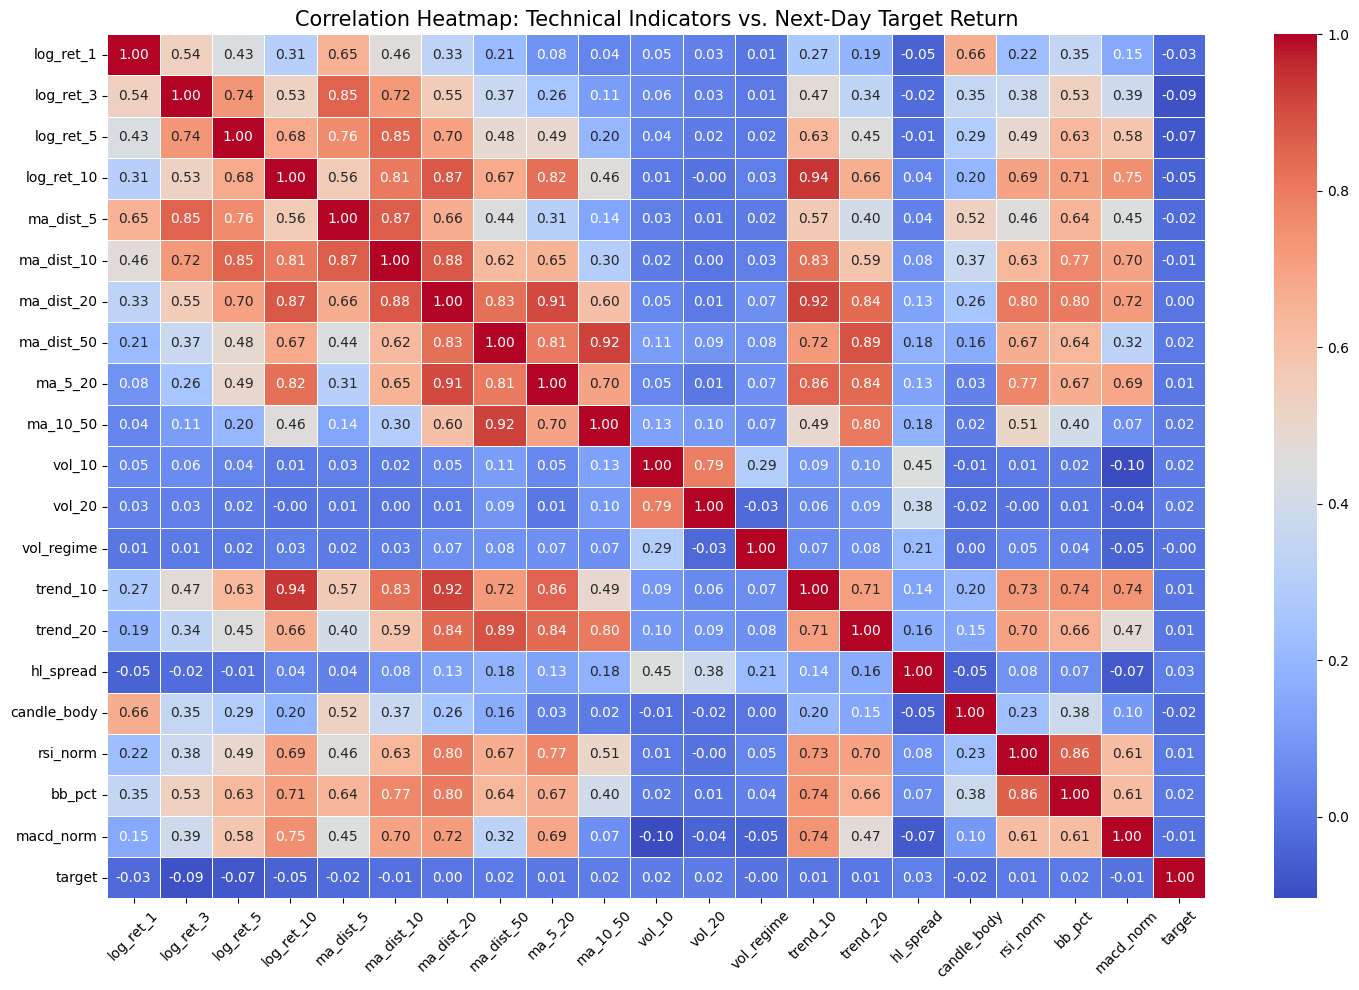

In [ ]:
split_date = df['date'].quantile(0.8)
train_df = df[df['date'] <= split_date].copy()

# Compute the correlation matrix for the features and the target
corr_matrix = train_df[FEATURE_COLS + ['target']].corr()

# Generate the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Technical Indicators vs. Next-Day Target Return', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Chronological train-test split

An 80/20 time based split is used. Random splits are inappropriate for financial time-series as they cause data leakage future information entering training.

In [ ]:
split_date = df['date'].quantile(0.8)
train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

train_df = train_df.dropna(subset=FEATURE_COLS + ['target'])
test_df = test_df.dropna(subset=FEATURE_COLS + ['target'])

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']
X_test = test_df[FEATURE_COLS]
y_test = test_df['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(train_df.shape, test_df.shape)
print(y_train.describe())

(165379, 32) (41300, 32)
count    165379.000000
mean          0.000251
std           0.073148
min          -8.121276
25%          -0.026629
50%           0.000100
75%           0.026042
max          12.086162
Name: target, dtype: float64


## Standardisation formula

$$z = \frac{x - \mu}{\sigma}$$

where $x$ is the original feature, $\mu$ is the training mean and $\sigma$ is the training standard deviation.
Fitting the scaler on training data only prevents any form of look ahead bias.

## Walk-Forward Validation

Standard single split backtests can overstate performance on non stationary financial data.
Walkforward validation expands the training window iteratively re evaluating on a held out forward period that the model has never seen. This is a more realistic proxy for live deployment.

In [ ]:
# Further Optimized Walk-Forward Validation
split_points = [0.6, 0.8]
wf_results = []

for split in split_points:
    cutoff1 = df['date'].quantile(split)
    cutoff2 = df['date'].quantile(min(split + 0.1, 0.99))

    tr = df[df['date'] <= cutoff1].copy()
    te = df[(df['date'] > cutoff1) & (df['date'] <= cutoff2)].copy()

    tr = tr.dropna(subset=FEATURE_COLS + ['target'])
    te = te.dropna(subset=FEATURE_COLS + ['target'])

    Xtr = tr[FEATURE_COLS]
    ytr = tr['target']
    Xte = te[FEATURE_COLS]
    yte = te['target']

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    rf_wf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    xgb_wf = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    rf_wf.fit(Xtr_s, ytr)
    xgb_wf.fit(Xtr_s, ytr)

    rf_pred = rf_wf.predict(Xte_s)
    xgb_pred = xgb_wf.predict(Xte_s)

    wf_results.append({
        'split': split,
        'rf_mae': mean_absolute_error(yte, rf_pred),
        'xgb_mae': mean_absolute_error(yte, xgb_pred)
    })

print('Fast walk-forward validation complete.')

Fast walk-forward validation complete.


In [ ]:
wf_df = pd.DataFrame(wf_results)
print(wf_df)
print("RF Mean MAE:", wf_df['rf_mae'].mean(), "±", wf_df['rf_mae'].std())
print("XGB Mean MAE:", wf_df['xgb_mae'].mean(), "±", wf_df['xgb_mae'].std())

   split    rf_mae   xgb_mae
0    0.6  0.025211  0.025225
1    0.8  0.035781  0.035778
RF Mean MAE: 0.03049583616375382 ± 0.007474126194624355
XGB Mean MAE: 0.03050127437188048 ± 0.007462249274663463


## Modelling approach

Five models are evaluated:

1. **Random Forest (RF)** — tree ensemble, strong non sequential baseline robust to outliers
2. **XGBoost (XGB)** — gradient boosted trees, widely used in financial prediction
3. **1D CNN** — captures local temporal patterns from rolling windows
4. **LSTM** — recurrent network designed for sequential dependencies
5. **GRU** — computationally efficient recurrent architecture

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

rf_pred  = rf.predict(X_test_scaled)

print("Random Forest and XGBoost trained successfully")
print(f"RF  prediction range: [{rf_pred.min():.4f}, {rf_pred.max():.4f}]")

Random Forest and XGBoost trained successfully
RF  prediction range: [-0.1939, 0.1306]


In [ ]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_test_scaled)

print("XGBoost trained successfully")
print(f"XGB prediction range: [{xgb_pred.min():.4f}, {xgb_pred.max():.4f}]")

XGBoost trained successfully
XGB prediction range: [-0.2757, 1.0573]


## Create rolling sequences for CNN, LSTM and GRU

Sequence models require 3D input of shape $(n, T, f)$ where:
- $n$ = number of samples
- $T$ = lookback window (20 timesteps)
- $f$ = number of features (27)

A lookback of 20 is used (versus 10 in the baseline) to give recurrent layers more temporal context.
The scaler fitted on the tabular training set to avoid a second fit.

In [ ]:
LOOKBACK = 20

def create_sequences(dataframe, feature_cols, target_col='target', lookback=20):
    X_seq, y_seq, meta = [], [], []
    for symbol, group in dataframe.groupby('symbol'):
        group = group.sort_values('date').reset_index(drop=True)
        X_vals = group[feature_cols].values
        y_vals = group[target_col].values
        dates  = group['date'].values
        for i in range(lookback, len(group)):
            X_seq.append(X_vals[i - lookback : i])
            y_seq.append(y_vals[i])
            meta.append((dates[i], symbol))
    return np.array(X_seq), np.array(y_seq), meta

# Re-use the same scaler fitted on train_df
seq_train_df = train_df.copy()
seq_test_df  = test_df.copy()
seq_train_df[FEATURE_COLS] = scaler.transform(seq_train_df[FEATURE_COLS])
seq_test_df[FEATURE_COLS]  = scaler.transform(seq_test_df[FEATURE_COLS])

X_train_seq, y_train_seq, train_meta = create_sequences(
    seq_train_df, FEATURE_COLS, lookback=LOOKBACK)
X_test_seq, y_test_seq, test_meta = create_sequences(
    seq_test_df, FEATURE_COLS, lookback=LOOKBACK)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print(f"Sequence shape: ({LOOKBACK} timesteps, {len(FEATURE_COLS)} features)")

X_train_seq: (163379, 20, 20)
X_test_seq : (39300, 20, 20)
Sequence shape: (20 timesteps, 20 features)


## EarlyStopping factory

A fresh `EarlyStopping` instance is created for each model to prevent internal state contamination across training runs.

In [ ]:
def get_early_stop(patience=8):
    """Return a fresh EarlyStopping instance. Must be called once per .fit() call."""
    return EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

## CNN model

The 1D CNN captures local temporal patterns from rolling windows.

In [ ]:
def build_cnn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=32, kernel_size=2, activation='relu'),
        Dropout(0.2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

cnn = build_cnn_model((X_train_seq.shape[1], X_train_seq.shape[2]))
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 9, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,457 (154.13 KB)

 Trainable params: 39,201 (153.13 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
cnn_history = cnn.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[get_early_stop(patience=3)],
    verbose=1
)
cnn_pred = cnn.predict(X_test_seq, batch_size=256).flatten()
print("CNN training complete. Predictions shape:", cnn_pred.shape)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - loss: 0.0062 - val_loss: 0.0033
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - loss: 0.0062 - val_loss: 0.0033
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - loss: 0.0059 - val_loss: 0.0033
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
CNN training complete. Predictions shape: (39300,)


## LSTM model

LSTM captures longer sequential dependencies in financial time-series data.

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

lstm = build_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
lstm_history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[get_early_stop(patience=3)],
    verbose=1
)
lstm_pred = lstm.predict(X_test_seq, batch_size=256).flatten()
print("LSTM training complete. Predictions shape:", lstm_pred.shape)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 54s 95ms/step - loss: 0.0653 - val_loss: 0.0047
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - loss: 0.0099 - val_loss: 0.0035
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 48s 94ms/step - loss: 0.0069 - val_loss: 0.0034
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 84s 98ms/step - loss: 0.0062 - val_loss: 0.0033
Epoch 5/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 49s 96ms/step - loss: 0.0061 - val_loss: 0.0033
Epoch 6/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - loss: 0.0060 - val_loss: 0.0033
Epoch 7/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 45s 87ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 8/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 9/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - loss: 0.0059 - val_loss: 0.0033
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step
LSTM training complete. Predictions shape: (39300,)


## GRU model

GRU is computationally efficient and closely aligned with the per asset recurrent design.

In [ ]:
def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

gru = build_gru_model((X_train_seq.shape[1], X_train_seq.shape[2]))
gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20, 64)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,393 (107.00 KB)

 Trainable params: 27,201 (106.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
gru_history = gru.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[get_early_stop(patience=3)],
    verbose=1
)
gru_pred = gru.predict(X_test_seq, batch_size=256).flatten()
print("GRU training complete. Predictions shape:", gru_pred.shape)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 62s 110ms/step - loss: 0.0914 - val_loss: 0.0057
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 58s 113ms/step - loss: 0.0132 - val_loss: 0.0036
Epoch 3/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - loss: 0.0078 - val_loss: 0.0034
Epoch 4/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 5/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - loss: 0.0062 - val_loss: 0.0033
Epoch 6/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - loss: 0.0060 - val_loss: 0.0033
Epoch 7/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 58s 114ms/step - loss: 0.0060 - val_loss: 0.0033
Epoch 8/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - loss: 0.0059 - val_loss: 0.0033
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
GRU training complete. Predictions shape: (39300,)


## Evaluate predictive performance

Models are evaluated on three metrics:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**Directional Accuracy (DA)** is also reported as the proportion of predictions where the model
correctly identifies the direction (up/down) of the next return. For portfolio construction,
DA is often more economically relevant than regression error.

In [ ]:
def get_metrics(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    da   = np.mean(np.sign(y_true) == np.sign(y_pred))  # directional accuracy
    return rmse, mae, r2, da

def print_metrics(name, y_true, y_pred):
    rmse, mae, r2, da = get_metrics(y_true, y_pred)
    print(f"{name}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  R2   : {r2:.6f}")
    print(f"  DA   : {da:.4f}  ({100*da:.1f}% directional accuracy)")
    print("-" * 40)

print_metrics("Random Forest", y_test,     rf_pred)
print_metrics("XGBoost",       y_test,     xgb_pred)
print_metrics("CNN",           y_test_seq, cnn_pred)
print_metrics("LSTM",          y_test_seq, lstm_pred)
print_metrics("GRU",           y_test_seq, gru_pred)

Random Forest
  RMSE : 0.050673
  MAE  : 0.034802
  R2   : 0.000111
  DA   : 0.4975  (49.7% directional accuracy)
----------------------------------------
XGBoost
  RMSE : 0.051083
  MAE  : 0.034957
  R2   : -0.016100
  DA   : 0.5008  (50.1% directional accuracy)
----------------------------------------
CNN
  RMSE : 0.051016
  MAE  : 0.034859
  R2   : -0.000614
  DA   : 0.4926  (49.3% directional accuracy)
----------------------------------------
LSTM
  RMSE : 0.051054
  MAE  : 0.034942
  R2   : -0.002097
  DA   : 0.4794  (47.9% directional accuracy)
----------------------------------------
GRU
  RMSE : 0.051045
  MAE  : 0.034935
  R2   : -0.001769
  DA   : 0.4922  (49.2% directional accuracy)
----------------------------------------


## Results comparison table

In [ ]:
common_len = min(len(y_test_seq), len(cnn_pred), len(lstm_pred), len(gru_pred))

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'CNN', 'LSTM', 'GRU'],
    'RMSE': [
        get_metrics(y_test,                  rf_pred)[0],
        get_metrics(y_test,                  xgb_pred)[0],
        get_metrics(y_test_seq[:common_len], cnn_pred[:common_len])[0],
        get_metrics(y_test_seq[:common_len], lstm_pred[:common_len])[0],
        get_metrics(y_test_seq[:common_len], gru_pred[:common_len])[0],
    ],
    'MAE': [
        get_metrics(y_test,                  rf_pred)[1],
        get_metrics(y_test,                  xgb_pred)[1],
        get_metrics(y_test_seq[:common_len], cnn_pred[:common_len])[1],
        get_metrics(y_test_seq[:common_len], lstm_pred[:common_len])[1],
        get_metrics(y_test_seq[:common_len], gru_pred[:common_len])[1],
    ],
    'R2': [
        get_metrics(y_test,                  rf_pred)[2],
        get_metrics(y_test,                  xgb_pred)[2],
        get_metrics(y_test_seq[:common_len], cnn_pred[:common_len])[2],
        get_metrics(y_test_seq[:common_len], lstm_pred[:common_len])[2],
        get_metrics(y_test_seq[:common_len], gru_pred[:common_len])[2],
    ],
    'Dir. Acc.': [
        get_metrics(y_test,                  rf_pred)[3],
        get_metrics(y_test,                  xgb_pred)[3],
        get_metrics(y_test_seq[:common_len], cnn_pred[:common_len])[3],
        get_metrics(y_test_seq[:common_len], lstm_pred[:common_len])[3],
        get_metrics(y_test_seq[:common_len], gru_pred[:common_len])[3],
    ]
})

results = results.sort_values('MAE').reset_index(drop=True)
print(results.to_string(index=False))
results

        Model     RMSE      MAE        R2  Dir. Acc.
Random Forest 0.050673 0.034802  0.000111   0.497482
          CNN 0.051016 0.034859 -0.000614   0.492595
          GRU 0.051045 0.034935 -0.001769   0.492239
         LSTM 0.051054 0.034942 -0.002097   0.479415
      XGBoost 0.051083 0.034957 -0.016100   0.500751


,Model,RMSE,MAE,R2,Dir. Acc.
0,Random Forest,0.050673,0.034802,0.000111,0.497482
1,CNN,0.051016,0.034859,-0.000614,0.492595
2,GRU,0.051045,0.034935,-0.001769,0.492239
3,LSTM,0.051054,0.034942,-0.002097,0.479415
4,XGBoost,0.051083,0.034957,-0.016100,0.500751


## Visual comparison of model performance

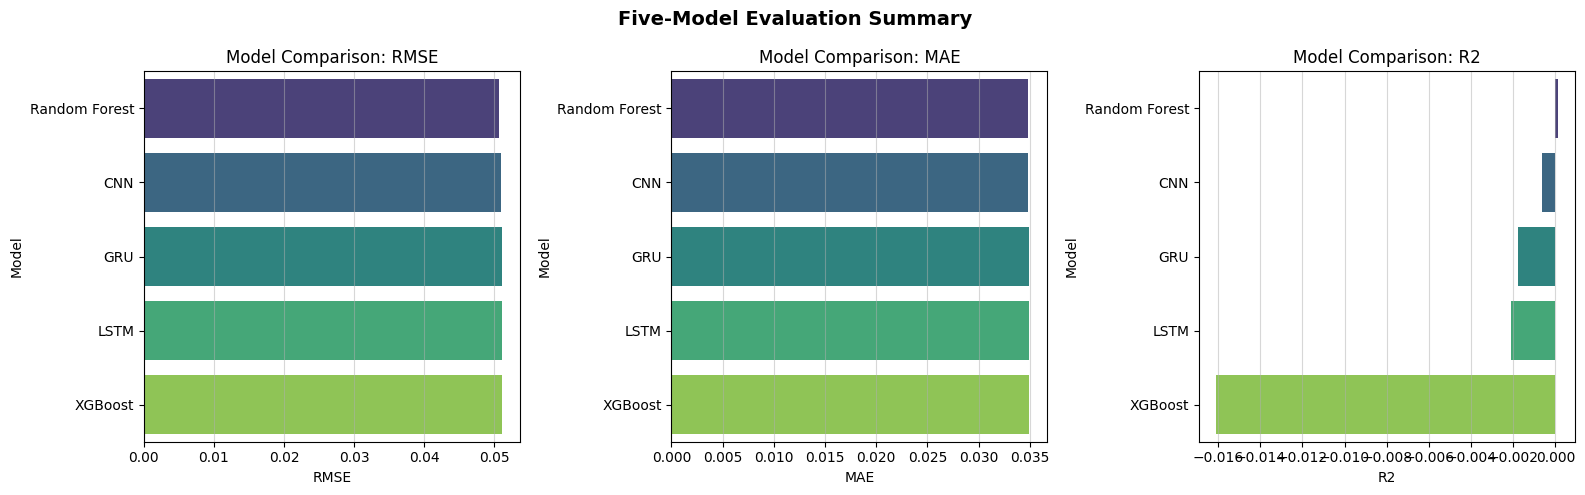

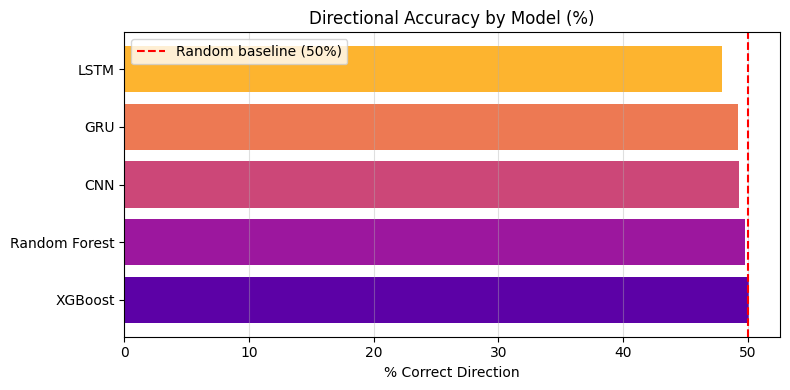

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R2']
for ax, metric in zip(axes, metrics):
    data = results.sort_values(metric, ascending=(metric != 'R2'))
    sns.barplot(data=data, x=metric, y='Model', palette='viridis', ax=ax)
    ax.set_title(f'Model Comparison: {metric}')
    ax.grid(True, axis='x', alpha=0.5)
plt.suptitle('Five-Model Evaluation Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Directional accuracy chart
plt.figure(figsize=(8, 4))
res_da = results.sort_values('Dir. Acc.', ascending=False)
bars = plt.barh(res_da['Model'], res_da['Dir. Acc.'] * 100, color=sns.color_palette('plasma', 5))
plt.axvline(50, color='red', linestyle='--', label='Random baseline (50%)')
plt.title('Directional Accuracy by Model (%)')
plt.xlabel('% Correct Direction')
plt.legend()
plt.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## Select the best model

The model with the lowest MAE is used for portfolio construction.

In [ ]:
best_model_name = results.iloc[0]['Model']
print(f"Best model by MAE: {best_model_name}")

pred_map = {
    'Random Forest': rf_pred,
    'XGBoost':       xgb_pred,
    'CNN':           cnn_pred,
    'LSTM':          lstm_pred,
    'GRU':           gru_pred,
}
best_pred = np.array(pred_map[best_model_name]).flatten()

Best model by MAE: Random Forest


## Portfolio backtest

The best model ranks assets daily by predicted return. The top-3 assets are held with
equal weighting, and a transaction cost of 10 basis points is applied per period:

$$r_{\text{net},t} = \frac{1}{N}\sum_{i=1}^{N} r_{\text{actual},i,t} - c$$

In [ ]:
common_len = min(len(test_meta), len(best_pred), len(y_test_seq))

meta_df = pd.DataFrame(test_meta[:common_len], columns=['date', 'symbol'])
meta_df['actual_return'] = y_test_seq[:common_len]
meta_df['pred_return']   = best_pred[:common_len]

TOP_N            = 3
TRANSACTION_COST = 0.001

portfolio_results = []
for dt, group in meta_df.groupby('date'):
    top_assets = group.sort_values('pred_return', ascending=False).head(TOP_N)
    avg_return = top_assets['actual_return'].mean()
    net_return = avg_return - TRANSACTION_COST
    portfolio_results.append([dt, net_return])

In [ ]:
portfolio_df = pd.DataFrame(portfolio_results, columns=['date', 'portfolio_return'])
portfolio_df = portfolio_df.sort_values('date').reset_index(drop=True)
portfolio_df['cumulative_return'] = (1 + portfolio_df['portfolio_return']).cumprod()

mean_ret     = portfolio_df['portfolio_return'].mean()
std_ret      = portfolio_df['portfolio_return'].std()
sharpe_ratio = (mean_ret / std_ret) * np.sqrt(252) if std_ret != 0 else np.nan
cum_max      = portfolio_df['cumulative_return'].cummax()
drawdown     = portfolio_df['cumulative_return'] / cum_max - 1
max_drawdown = drawdown.min()
total_return = portfolio_df['cumulative_return'].iloc[-1] - 1
volatility   = std_ret * np.sqrt(252)

In [ ]:
print(f"{best_model_name} Strategy Performance")
print(f"Total Return       : {total_return:.4f}  ({100*total_return:.1f}%)")
print(f"Sharpe Ratio       : {sharpe_ratio:.4f}")
print(f"Max Drawdown       : {max_drawdown:.4f}  ({100*max_drawdown:.1f}%)")
print(f"Annualised Vol     : {volatility:.4f}")
portfolio_df.head()

Random Forest Strategy Performance
Total Return       : -0.5482  (-54.8%)
Sharpe Ratio       : -0.4317
Max Drawdown       : -0.6330  (-63.3%)
Annualised Vol     : 0.6650


,date,portfolio_return,cumulative_return
0,2024-07-08,0.018797,1.018797
1,2024-07-09,0.011896,1.030917
2,2024-07-10,-0.022263,1.007965
3,2024-07-11,0.019305,1.027424
4,2024-07-12,0.007673,1.035307


## Risk and performance metrics illustration via Cumulative Return Plot

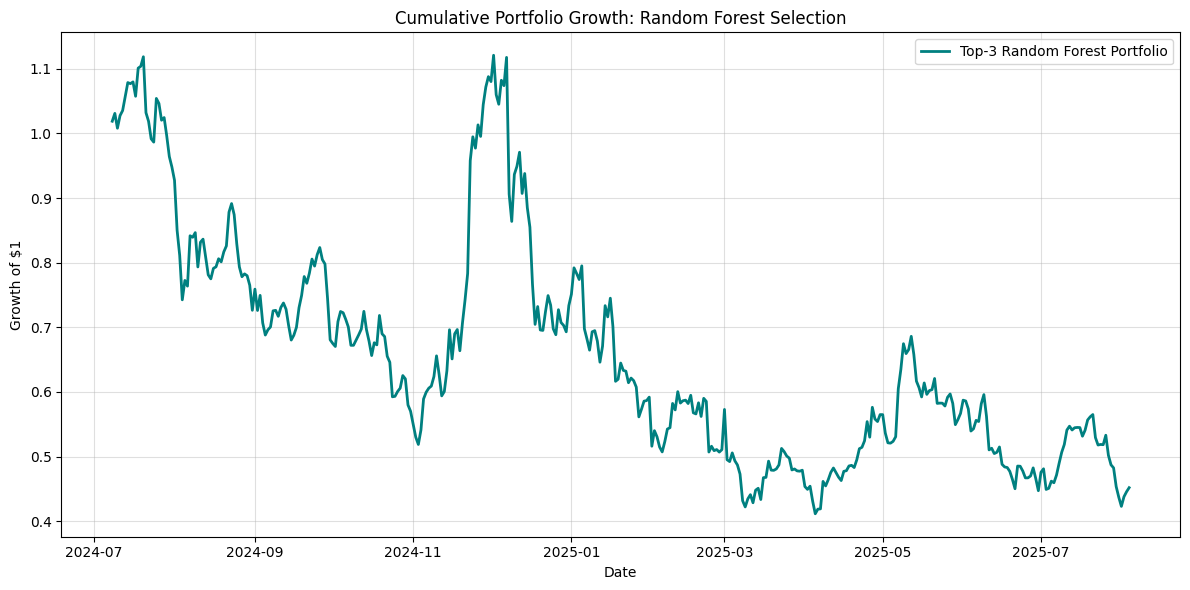

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_df['date'], portfolio_df['cumulative_return'],
         label=f'Top-{TOP_N} {best_model_name} Portfolio', color='teal', linewidth=2)
plt.title(f'Cumulative Portfolio Growth: {best_model_name} Selection')
plt.xlabel('Date'); plt.ylabel('Growth of $1')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## Benchmark comparison: AI Portfolio vs Equal-Weight

Outperformance over the equal weight benchmark is the primary validation criterion.

In [ ]:
ew_daily = (test_df.groupby('date')['target']
                    .mean()
                    .reset_index()
                    .rename(columns={'target': 'ew_return'})
                    .sort_values('date')
                    .reset_index(drop=True))
ew_daily['ew_cum'] = (1 + ew_daily['ew_return']).cumprod()

comparison = portfolio_df.merge(ew_daily[['date', 'ew_cum']], on='date', how='inner')
ew_sharpe  = (ew_daily['ew_return'].mean() / ew_daily['ew_return'].std()) * np.sqrt(252)

print(f"AI Portfolio Sharpe  : {sharpe_ratio:.4f}")
print(f"EW Benchmark Sharpe  : {ew_sharpe:.4f}")
print(f"Sharpe Alpha         : {sharpe_ratio - ew_sharpe:.4f}")

AI Portfolio Sharpe  : -0.4317
EW Benchmark Sharpe  : -0.1979
Sharpe Alpha         : -0.2338


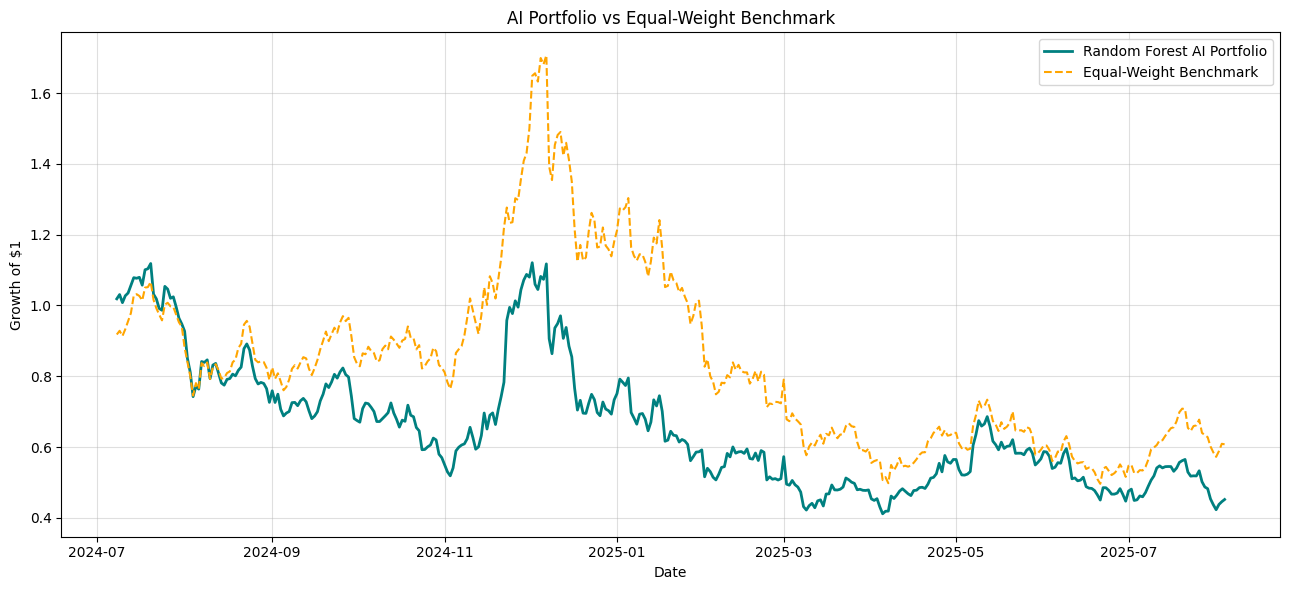

In [ ]:
plt.figure(figsize=(13, 6))
plt.plot(comparison['date'], comparison['cumulative_return'],
         label=f'{best_model_name} AI Portfolio', color='teal', linewidth=2)
plt.plot(comparison['date'], comparison['ew_cum'],
         label='Equal-Weight Benchmark', color='orange', linestyle='--', linewidth=1.5)
plt.title('AI Portfolio vs Equal-Weight Benchmark')
plt.xlabel('Date'); plt.ylabel('Growth of $1')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## Drawdown analysis

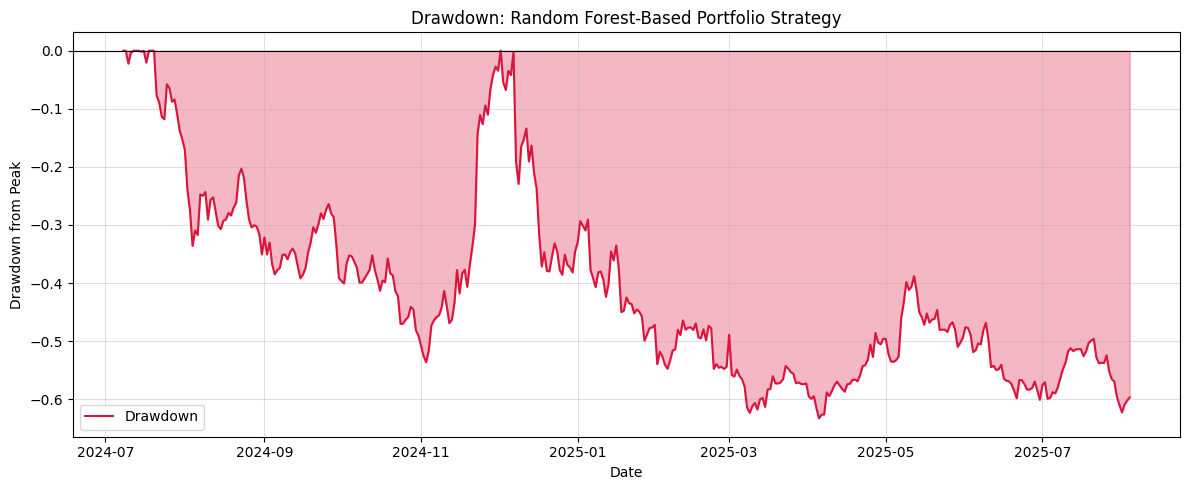

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(portfolio_df['date'], drawdown, color='crimson', label='Drawdown')
plt.axhline(0, color='black', linewidth=0.8)
plt.fill_between(portfolio_df['date'], drawdown, 0, alpha=0.3, color='crimson')
plt.title(f'Drawdown: {best_model_name}-Based Portfolio Strategy')
plt.xlabel('Date'); plt.ylabel('Drawdown from Peak')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## Final interpretation

In [ ]:
print(f"=== FINAL SUMMARY ===")
print(f"Best forecasting model  : {best_model_name}")
print(f"Total return            : {total_return:.4f} ({100*total_return:.1f}%)")
print(f"Sharpe ratio            : {sharpe_ratio:.4f}")
print(f"Max drawdown            : {max_drawdown:.4f} ({100*max_drawdown:.1f}%)")
print(f"Annualised volatility   : {volatility:.4f}")
print()
print("Key improvements:")
print("  1. All symbols used (~200k rows)")
print("  2. ratio normalised features")
print("  3. Log-return target with winsorisation (skew reduced from 17.6)")
print("  4. Lookback = 20 for sequence models")
print("  5. Stacked LSTM/GRU with BatchNorm")
print("  6. Directional accuracy reported as additional metric")

=== FINAL SUMMARY ===
Best forecasting model  : Random Forest
Total return            : -0.5482 (-54.8%)
Sharpe ratio            : -0.4317
Max drawdown            : -0.6330 (-63.3%)
Annualised volatility   : 0.6650

Key improvements:
  1. All symbols used (~200k rows)
  2. ratio normalised features
  3. Log-return target with winsorisation (skew reduced from 17.6)
  4. Lookback = 20 for sequence models
  5. Stacked LSTM/GRU with BatchNorm
  6. Directional accuracy reported as additional metric


## SHAP feature importance (Random Forest)

SHAP (SHapley Additive exPlanations) quantifies each feature's marginal contribution to model predictions.

In [ ]:
sample_size = min(2000, X_test_scaled.shape[0])
X_shap = pd.DataFrame(X_test_scaled[:sample_size], columns=FEATURE_COLS)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)
print("SHAP values computed successfully")

SHAP values computed successfully


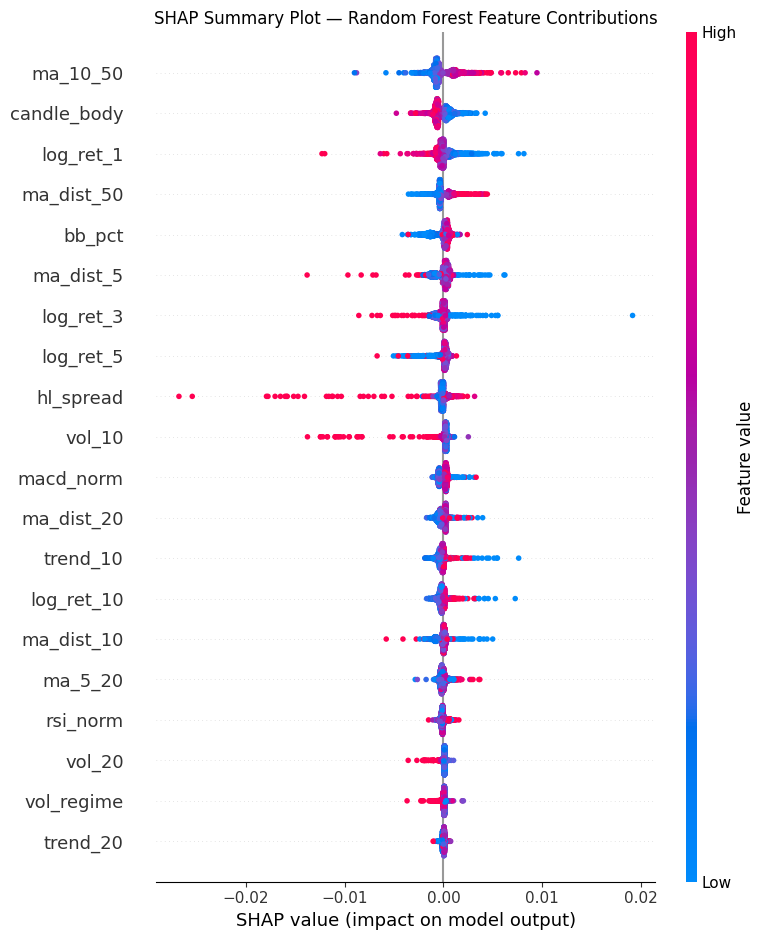

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Summary Plot — Random Forest Feature Contributions')
plt.tight_layout(); plt.show()

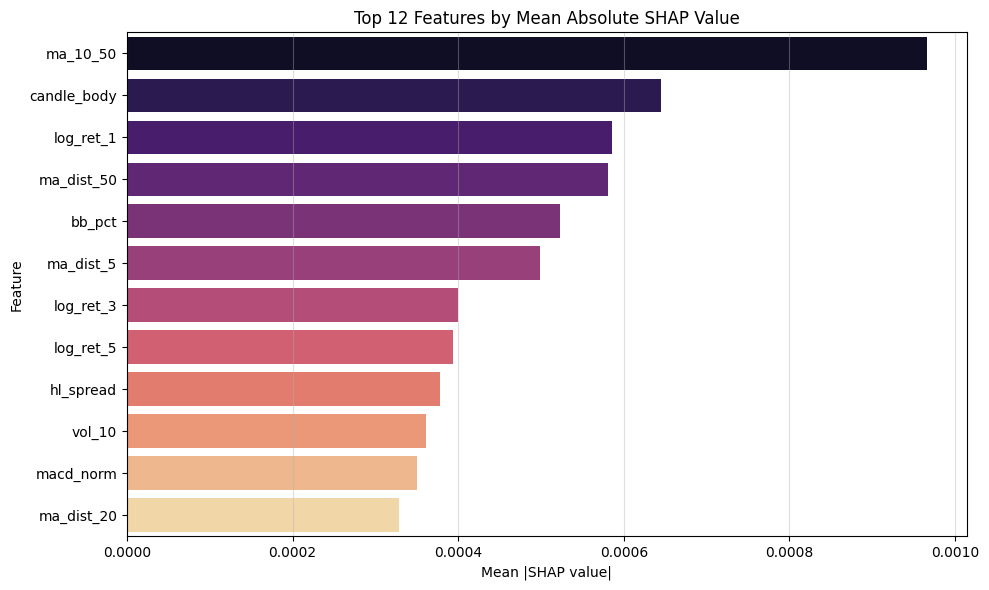

In [ ]:
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': FEATURE_COLS, 'MeanAbsSHAP': shap_importance})
shap_df = shap_df.sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_df.head(12), x='MeanAbsSHAP', y='Feature', palette='magma')
plt.title('Top 12 Features by Mean Absolute SHAP Value')
plt.xlabel('Mean |SHAP value|'); plt.ylabel('Feature')
plt.grid(True, axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

In [ ]:
print("\nTop 5 most influential features:")
print(shap_df.head(5).to_string(index=False))


Top 5 most influential features:
    Feature  MeanAbsSHAP
   ma_10_50     0.000966
candle_body     0.000646
  log_ret_1     0.000585
 ma_dist_50     0.000581
     bb_pct     0.000523


# Thank you Mr. Furqan Rustam